In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import sympy as sp

 - https://www.wolframalpha.com/input?i=solve+k1+*+x+%2B+k2+*+ln%28k3+*+x%29+%3D+k4+*+t+for+x

$$
\begin{align}
k_1 x + k_2 \ln(k_3 x) &= k_4 t \\
\Leftrightarrow \frac{k_1}{k_2}x + \ln(k_3 x) &= \frac{k_4}{k_2}t \\
\Leftrightarrow \exp\left(\frac{k_1}{k_2} x\right) \frac{k_1}{k_2} x &= \frac{k_1}{k_2k_3}\exp\left(\frac{k_4}{k_2}t\right) \\
\Leftrightarrow x &= \frac{k_2}{k_1} W_0 \left[\frac{k_1}{k_2k_3}\exp\left(\frac{k_4}{k_2}t\right)\right]
\end{align}
$$

In [2]:
x, t, k1, k2, k3, k4 = sp.symbols("x t k1 k2 k3 k4")

In [3]:
h1 = k1 * x + k2 * sp.ln(k3 * x)
h2 = k4 * t

In [4]:
solutions = sp.solve(sp.Eq(h1, h2), x)

In [5]:
solutions[0]

k2*LambertW(k1*exp(k4*t/k2)/(k2*k3))/k1

In [6]:
def t_func(x, k1, k2, k3, k4):
    return (1. / k4) * (k1 * x + k2 * np.log(k3 * x))

In [7]:
def x_func(t, k1, k2, k3, k4):
    return np.real((k2 / k1) * special.lambertw((k1 / (k2 * k3)) * np.exp((k4 / k2) * t)))

In [8]:
p0 = (1., 10., 100., -10)

In [9]:
tlin = np.linspace(0., 1., 300)

In [10]:
x = x_func(tlin, *p0)

In [11]:
xlin = np.linspace(x.min(), x.max(), 300)

In [12]:
t = t_func(xlin, *p0)

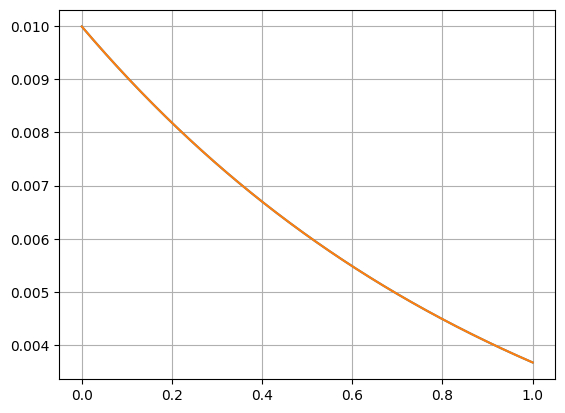

In [13]:
fig, axe = plt.subplots()
axe.plot(tlin, x)
axe.plot(t, xlin)
axe.grid()